=============== bài toán hồi quy tuyến tính ==============

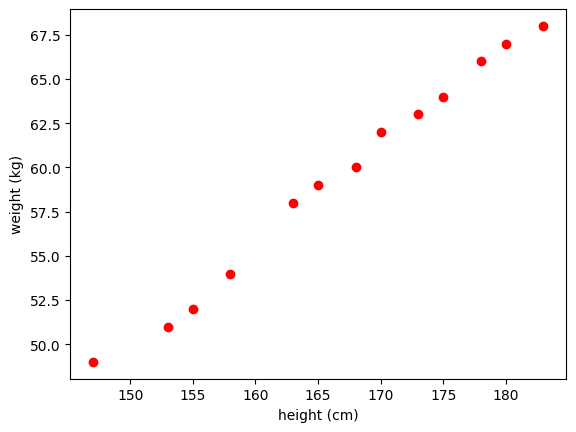

w = [-34.75981904   0.56498046]


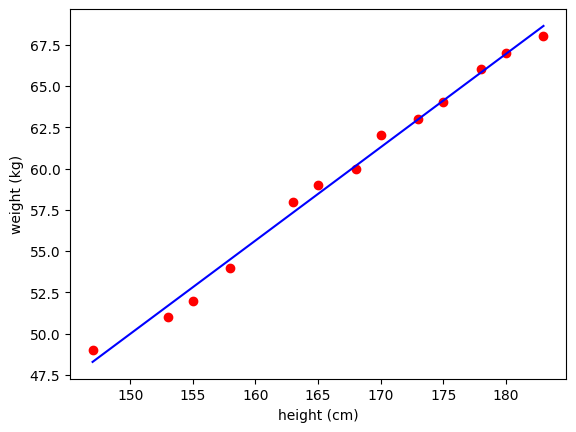

[[49.98725067]
 [55.63705532]]
Height: [150] True weight: 50 Predicted weight: [49.98725067]
Height: [160] True weight: 56 Predicted weight: [55.63705532]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# =====================================================
# Tạo dữ liệu chiều cao và cân nặng
# =====================================================
X = np.array([[147,153,155,158,163,165,168,
               170,173,175,178,180,183]]).T
Y = np.array([49,51,52,54,58,59,60,
              62,63,64,66,67,68])

# =====================================================
# Vẽ dữ liệu gốc
# =====================================================
plt.plot(X, Y, 'o', color='red')
plt.xlabel('height (cm)')
plt.ylabel('weight (kg)')
plt.show()

# =====================================================
# Tạo ma trận mở rộng
# Thêm cột 1 để tính bias w0
# =====================================================
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis=1)

# =====================================================
# Tính nghiệm hồi quy tuyến tính
# Công thức:
# w = (X^T X)^-1 X^T y
# =====================================================
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, Y)
w = np.dot(np.linalg.pinv(A), b)

# =====================================================
# Hiển thị trọng số
# w[0] = bias
# w[1] = hệ số góc
# =====================================================
print("w =", w)

# =====================================================
# Dự đoán dữ liệu theo mô hình
# y = w1*x + w0
# =====================================================
y = np.dot(X, w[1]) + w[0]

# =====================================================
# Vẽ đường hồi quy tuyến tính
# =====================================================
plt.plot(X, Y, 'o', color='red')
plt.plot(X, y, color='blue')
plt.xlabel('height (cm)')
plt.ylabel('weight (kg)')
plt.show()

# =====================================================
# Tạo dữ liệu kiểm tra
# =====================================================
X_test = np.array([[150, 160]]).T
Y_test = ([50, 56])

# =====================================================
# Dự đoán cân nặng từ chiều cao
# =====================================================
Y_predict = np.dot(X_test, w[1]) + w[0]

# =====================================================
# Hiển thị kết quả dự đoán
# =====================================================
print(Y_predict)
print('Height:', X_test[0],
      'True weight:', Y_test[0],
      'Predicted weight:', Y_predict[0])
print('Height:', X_test[1],
      'True weight:', Y_test[1],
      'Predicted weight:', Y_predict[1])

=============== Thuật toán hồi quy logictis ==================

In [ ]:
import numpy as np

# =====================================================
# Hàm sigmoid
# Chuyển giá trị đầu ra về khoảng [0, 1]
# =====================================================
def sigmoid(x):
    return 1/(1 + np.exp(-x))

# =====================================================
# Hàm tính xác suất dự đoán
# =====================================================
def prob(w, X):
    return sigmoid(X.dot(w))

# =====================================================
# Hàm mất mát (Loss Function)
# Bao gồm:
# - Cross Entropy Loss
# - Weight Decay (Regularization)
# =====================================================
def loss(w, X, y, lam_):
    # Tính xác suất dự đoán
    a = prob(w, X)
    # Hàm mất mát Cross Entropy
    loss_0 = -np.mean(y * np.log(a) + (1-y) * np.log(1-a))
    # Thành phần regularization
    weight_decay = 0.5 * lam_/X.shape[0] * np.sum(w * w)
    # Tổng loss
    return loss_0 + weight_decay

# =====================================================
# Thuật toán Logistic Regression
# Huấn luyện bằng Gradient Descent
# =====================================================
def logistic_reg(w_init, X, y, lam_, lr=0.1, epoch=100):
    # N: số lượng mẫu dữ liệu
    # d: số chiều dữ liệu
    N, d = X.shape[0], X.shape[1]
    # Khởi tạo trọng số
    w = w_old = w_init
    # Lưu lịch sử loss
    loss_hist = [loss(w_init, X, y, lam_)]
    ep = 0
    # Lặp theo số epoch
    while ep < epoch:
        ep += 1
        # Trộn ngẫu nhiên dữ liệu
        ids = np.random.permutation(N)
        # Duyệt từng mẫu dữ liệu
        for i in ids:
            # Lấy mẫu dữ liệu thứ i
            xi = X[i]
            # Nhãn thực tế
            yi = y[i]
            # Tính xác suất dự đoán
            ai = sigmoid(xi.dot(w))
            # Cập nhật trọng số
            w = w - lr * ((ai - yi) * xi + lam_ * w)
            # Lưu loss sau mỗi lần cập nhật
            loss_hist.append(loss(w, X, y, lam_))
        # Điều kiện dừng
        if np.linalg.norm(w - w_old) / d < 1e-6:
            break
        # Cập nhật trọng số cũ
        w_old = w
    return w, loss_hist

# =====================================================
# Tạo dữ liệu huấn luyện
# =====================================================
# Đặt seed để kết quả ngẫu nhiên luôn giống nhau
np.random.seed(2)
# Dữ liệu số giờ ôn thi
X = np.array([
    [0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 1.75, 2.0,
     2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 4.0, 4.25,
     4.5, 4.75, 5.0, 5.5]
]).T
# Nhãn:
# 0 = rớt
# 1 = đậu
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
              1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

# =====================================================
# Thêm cột bias vào dữ liệu
# =====================================================
Xbar = np.concatenate((X, np.ones((X.shape[0], 1))), axis=1)

# =====================================================
# Khởi tạo trọng số ban đầu ngẫu nhiên
# =====================================================
w_init = np.random.rand(Xbar.shape[1])

# =====================================================
# Hệ số regularization
# =====================================================
lam_ = 0.0001

# =====================================================
# Huấn luyện mô hình Logistic Regression
# =====================================================
w, loss_hist = logistic_reg(
    w_init,
    Xbar,
    y,
    lam_,
    lr=0.05,
    epoch=10
)

# =====================================================
# Hiển thị kết quả
# =====================================================
print('Weight:', w)
print('Final Loss:', loss_hist[len(loss_hist)-1])

Weight: [ 0.6575503  -1.10545458]
Final Loss: 0.46126847519192077


================= Thuật toán KNN ====================

In [ ]:
import numpy as np
from sklearn import neighbors, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =====================================================
# LOAD DATASET IRIS
# =====================================================
# Load bộ dữ liệu Iris có sẵn trong sklearn
iris = datasets.load_iris()
# Dữ liệu đầu vào (4 đặc trưng của hoa)
iris_X = iris.data
# Nhãn đầu ra (loại hoa)
iris_y = iris.target

# =====================================================
# CHIA DỮ LIỆU TRAIN / TEST
# =====================================================
# Cố định random để mỗi lần chạy cho kết quả giống nhau
np.random.seed(7)
# Chia dữ liệu:
# - X_train, y_train: dùng để huấn luyện
# - X_test, y_test: dùng để kiểm tra
# test_size = 130 nghĩa là:
# - 130 mẫu test
# - 20 mẫu train
X_train, X_test, y_train, y_test = train_test_split(
    iris_X,
    iris_y,
    test_size=130
)

# =====================================================
# KNN VỚI 1 LÁNG GIỀNG GẦN NHẤT (1NN)
# =====================================================
# Tạo mô hình KNN:
# - n_neighbors = 1: dùng 1 điểm gần nhất
# - p = 2: dùng khoảng cách Euclidean (L2 norm)
model = neighbors.KNeighborsClassifier(
    n_neighbors=1,
    p=2
)
# Huấn luyện mô hình bằng dữ liệu train
model.fit(X_train, y_train)
# Dự đoán nhãn cho dữ liệu test
y_pred = model.predict(X_test)
# In ra độ chính xác
print(
    'Accuracy of 1NN: {:.2f} %'
    .format(100 * accuracy_score(y_test, y_pred))
)

# =====================================================
# KNN VỚI 7 LÁNG GIỀNG GẦN NHẤT (7NN)
# =====================================================
# Dùng 7 điểm gần nhất để bỏ phiếu
model = neighbors.KNeighborsClassifier(
    n_neighbors=7,
    p=2
)
# Huấn luyện mô hình
model.fit(X_train, y_train)
# Dự đoán dữ liệu test
y_pred = model.predict(X_test)
# In độ chính xác
print(
    'Accuracy of 7NN: {:.2f} %'
    .format(100 * accuracy_score(y_test, y_pred))
)

# =====================================================
# KNN CÓ TRỌNG SỐ THEO KHOẢNG CÁCH
# =====================================================
# weights='distance'
# Điểm càng gần thì ảnh hưởng càng lớn
model = neighbors.KNeighborsClassifier(
    n_neighbors=7,
    p=2,
    weights='distance'
)
# Huấn luyện mô hình
model.fit(X_train, y_train)
# Dự đoán dữ liệu test
y_pred = model.predict(X_test)
# In độ chính xác
print(
    'Accuracy of 7NN (1/distance weight): {:.2f} %'
    .format(100 * accuracy_score(y_test, y_pred))
)

# =====================================================
# TẠO HÀM TRỌNG SỐ RIÊNG
# =====================================================
# distances: khoảng cách từ điểm test
# tới các điểm hàng xóm
def myweight(distances):

    # sigma2 điều khiển độ giảm trọng số
    sigma2 = 0.4

    # Hàm Gaussian:
    # khoảng cách càng xa -> trọng số càng nhỏ
    return np.exp(-distances**2 / sigma2)

# =====================================================
# KNN DÙNG CUSTOM WEIGHT
# =====================================================
model = neighbors.KNeighborsClassifier(
    n_neighbors=7,
    p=2,
    weights=myweight
)
# Huấn luyện mô hình
model.fit(X_train, y_train)
# Dự đoán dữ liệu test
y_pred = model.predict(X_test)
# In độ chính xác
print(
    'Accuracy of 7NN (customized weight): {:.2f} %'
    .format(100 * accuracy_score(y_test, y_pred))
)

Accuracy of 1NN: 92.31 %
Accuracy of 7NN: 93.85 %
Accuracy of 7NN (1/distance weight): 94.62 %
Accuracy of 7NN (customized weight): 95.38 %


=============== Thuật toán K-means ==================

Shape of mnist data: (70000, 784)


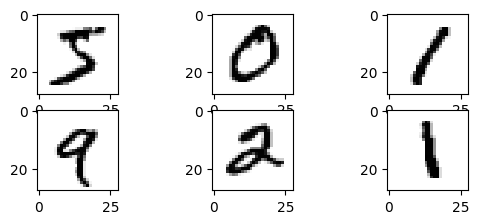

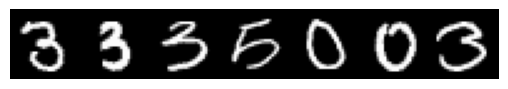

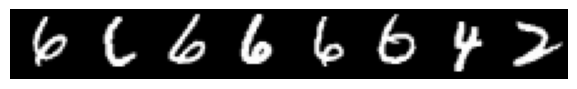

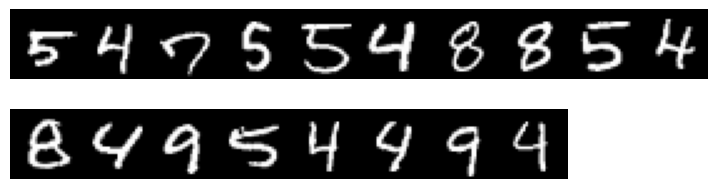

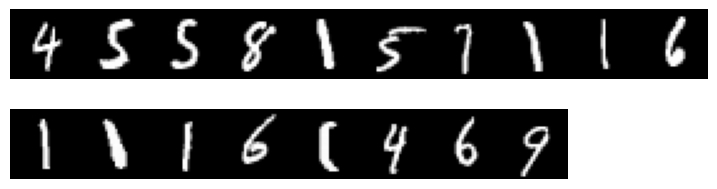

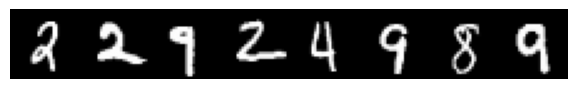

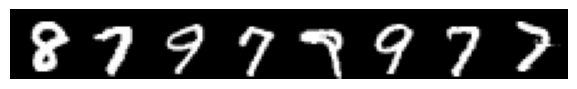

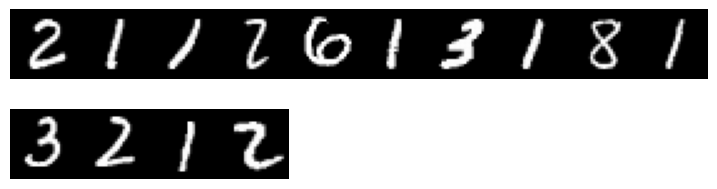

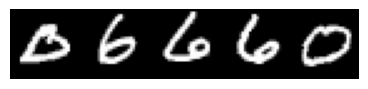

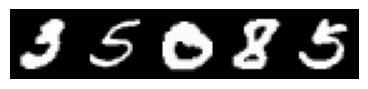

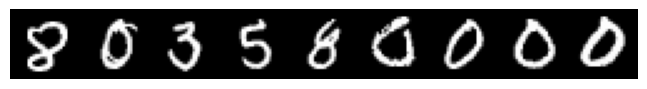

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
# from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# =====================================================
# Tải bộ dữ liệu MNIST
# =====================================================
mnist = fetch_openml('mnist_784', version=1)
print('Shape of mnist data:', mnist.data.shape)

# =====================================================
# Hiển thị các chữ số
# =====================================================
image = mnist.data.to_numpy()
plt.subplot(431)
plt.imshow(
    image[0].reshape(28, 28),
    cmap=plt.cm.gray_r,
    interpolation='nearest'
)
plt.subplot(432)
plt.imshow(
    image[1].reshape(28, 28),
    cmap=plt.cm.gray_r,
    interpolation='nearest'
)
plt.subplot(433)
plt.imshow(
    image[3].reshape(28, 28),
    cmap=plt.cm.gray_r,
    interpolation='nearest'
)
plt.subplot(434)
plt.imshow(
    image[4].reshape(28, 28),
    cmap=plt.cm.gray_r,
    interpolation='nearest'
)
plt.subplot(435)
plt.imshow(
    image[5].reshape(28, 28),
    cmap=plt.cm.gray_r,
    interpolation='nearest'
)
plt.subplot(436)
plt.imshow(
    image[6].reshape(28, 28),
    cmap=plt.cm.gray_r,
    interpolation='nearest'
)
plt.savefig('digits.png')
plt.show()

# =====================================================
# Phân cụm K-means bằng Scikit-learn
# =====================================================
K = 10   # 10 chữ số
N = 100  # 100 mẫu dữ liệu
X = mnist.data.loc[
    np.random.choice(mnist.data.shape[0], N)
]
kmeans = KMeans(n_clusters=K).fit(X)
pred_y = kmeans.predict(X)

# =====================================================
# Các hàm dùng để hiển thị chữ số
# =====================================================
def plot_d(digit):
    plt.axis('off')
    plt.imshow(
        digit.reshape((28, 28)),
        cmap=plt.cm.gray
    )
def plot_ds(digits):
    n = digits.shape[0]
    n_rows = 10
    n_cols = 10
    plt.figure(figsize=(n_cols * 0.9, n_rows * 1.3))
    plt.subplots_adjust(wspace=0, hspace=0)
    # plt.suptitle(title)
    for i in range(n):
        plt.subplot(n_rows, n_cols, i + 1)
        plot_d(digits[i, :])

# =====================================================
# Hiển thị các chữ số sau khi phân cụm
# =====================================================
for i in range(10):
    indices = np.where(pred_y == i)
    plot_ds(X.values[indices[0]])
plt.show()

=========== Mạng MLP với tập dữ liệu MNIST =============

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.60MB/s]


Epoch 1, Loss: 0.1134
Epoch 2, Loss: 0.1764
Epoch 3, Loss: 0.2432
Epoch 4, Loss: 0.0109
Epoch 5, Loss: 0.0308
Epoch 6, Loss: 0.1007
Epoch 7, Loss: 0.0863
Epoch 8, Loss: 0.0379
Epoch 9, Loss: 0.0478
Epoch 10, Loss: 0.0261
Accuracy: 0.9782


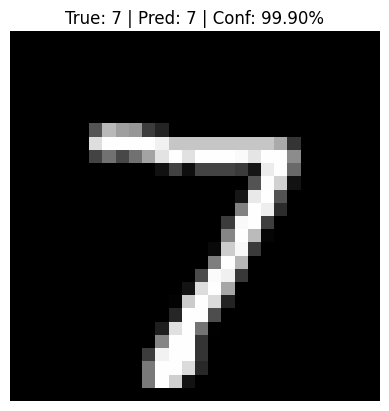

Prediction Correct


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
# =====================================================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# =====================================================
# Chuyển ảnh thành Tensor và chuẩn hóa về [0,1]
transform = transforms.ToTensor()

# =====================================================
# 2. NẠP DỮ LIỆU MNIST
# =====================================================
# Tải và tiền xử lý dataset MNIST cho tập train
train_loader = DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=64,             # Mỗi batch gồm 64 ảnh
    shuffle=True               # Trộn dữ liệu mỗi epoch
)
# Tải và tiền xử lý dataset MNIST cho tập test
test_loader = DataLoader(
    datasets.MNIST('./data', train=False, download=True, transform=transform),
    batch_size=64              # Batch size cho test
)

# =====================================================
# 3. XÂY DỰNG MÔ HÌNH MLP
# =====================================================
model = nn.Sequential(
    # Chuyển ảnh 28x28 -> vector 784 phần tử
    nn.Flatten(),
    # Fully Connected Layer: 784 -> 128 neuron
    nn.Linear(28 * 28, 128),
    # Hàm kích hoạt ReLU
    nn.ReLU(),
    # Layer đầu ra: 128 -> 10 lớp số từ 0 đến 9
    nn.Linear(128, 10)
)

# =====================================================
# 4. HÀM LOSS VÀ OPTIMIZER
# =====================================================
# Hàm mất mát cho bài toán phân loại
loss_fn = nn.CrossEntropyLoss()
# Optimizer Adam để cập nhật trọng số
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Learning rate

# =====================================================
# 5. HUẤN LUYỆN MÔ HÌNH
# =====================================================
for epoch in range(10):       # Train 10 epoch
    # Duyệt từng batch dữ liệu
    for images, labels in train_loader:
        # Xóa gradient cũ
        optimizer.zero_grad()
        # Forward: đưa ảnh qua model
        outputs = model(images)
        # Tính loss giữa dự đoán và nhãn thật
        loss = loss_fn(outputs, labels)
        # Backpropagation
        loss.backward()
        # Cập nhật trọng số
        optimizer.step()

    # In loss sau mỗi epoch
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# =====================================================
# 6. ĐÁNH GIÁ MÔ HÌNH
# =====================================================
correct = 0

# Tắt gradient để tăng tốc độ test
with torch.no_grad():
    # Duyệt dữ liệu test
    for images, labels in test_loader:
        # Lấy lớp có xác suất cao nhất
        pred = model(images).argmax(1)
        # Đếm số dự đoán đúng
        correct += (pred == labels).sum().item()

# =====================================================
# 7. IN ĐỘ CHÍNH XÁC
# =====================================================
print("Accuracy:", correct / len(test_loader.dataset))

# =====================================================
# 8. DỰ ĐOÁN MỘT ẢNH MẪU
# =====================================================
# Lấy ảnh đầu tiên trong tập test
pred_image, pred_label = test_loader.dataset[0]
# Thêm chiều batch để đưa vào model
# Shape từ [1, 28, 28] -> [1, 1, 28, 28]
pred_image_input = pred_image.unsqueeze(0)
# Tắt gradient để tăng tốc suy luận
with torch.no_grad():
    # Forward ảnh qua model
    output = model(pred_image_input)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    confidence, predicted_class = torch.max(probabilities, 1)
    # Lấy nhãn dự đoán
    prediction = predicted_class.item()

# =====================================================
# 9. HIỂN THỊ KẾT QUẢ DỰ ĐOÁN
# =====================================================
# Hiển thị ảnh grayscale
plt.imshow(pred_image.squeeze(), cmap='gray')
# Hiển thị nhãn thật và nhãn dự đoán
plt.title(f'True: {pred_label} | Pred: {prediction} | Conf: {confidence.item()*100:.2f}%')
# Ẩn trục tọa độ
plt.axis('off')
# Hiển thị cửa sổ ảnh
plt.show()

========== Mạng CNN với tập dữ liệu CIFAR-10 ===========

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


Epoch 1, Loss: 1.0960
Epoch 2, Loss: 1.2822
Epoch 3, Loss: 0.8640
Epoch 4, Loss: 0.6088
Epoch 5, Loss: 0.4166
Epoch 6, Loss: 1.0907
Epoch 7, Loss: 0.7767
Epoch 8, Loss: 0.6293
Epoch 9, Loss: 0.6853
Epoch 10, Loss: 0.4140
Accuracy: 0.7047


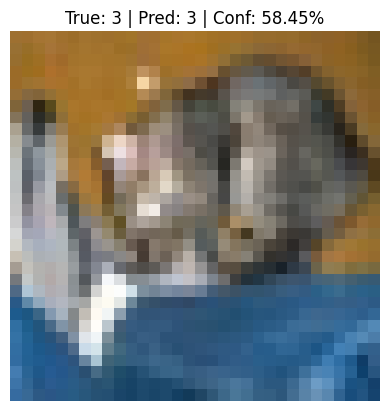

Prediction Correct


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# =====================================================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# =====================================================
# Chuyển ảnh về Tensor và chuẩn hóa dữ liệu
transform = transforms.ToTensor()

# =====================================================
# 2. NẠP DỮ LIỆU CIFAR-10
# =====================================================
# Tải và tiền xử lý dataset CIFAR-10 cho tập train
train_loader = DataLoader(
    datasets.CIFAR10('./data', train=True, download=True, transform=transform),
    batch_size=64,
    shuffle=True
)
# Tải và tiền xử lý dataset CIFAR-10 cho tập test
test_loader = DataLoader(
    datasets.CIFAR10('./data', train=False, download=True, transform=transform),
    batch_size=64
)

# =====================================================
# 3. XÂY DỰNG MÔ HÌNH CNN
# =====================================================
model = nn.Sequential(
    # Convolution Layer: 3 kênh màu -> 32 feature maps
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    # Hàm kích hoạt ReLU
    nn.ReLU(),
    # Giảm kích thước ảnh xuống 2 lần
    nn.MaxPool2d(2),
    # Convolution Layer: 32 -> 64 feature maps
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    # Hàm kích hoạt ReLU
    nn.ReLU(),
    # Giảm kích thước ảnh xuống 2 lần
    nn.MaxPool2d(2),
    # Chuyển feature map thành vector
    nn.Flatten(),
    # Fully Connected Layer
    nn.Linear(64 * 8 * 8, 128),
    # Hàm kích hoạt ReLU
    nn.ReLU(),
    # Layer đầu ra gồm 10 lớp
    nn.Linear(128, 10)
)

# =====================================================
# 4. HÀM LOSS VÀ OPTIMIZER
# =====================================================
# Hàm mất mát cho bài toán phân loại
loss_fn = nn.CrossEntropyLoss()
# Optimizer Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# =====================================================
# 5. HUẤN LUYỆN MÔ HÌNH
# =====================================================
for epoch in range(10):
    for images, labels in train_loader:
        # Xóa gradient cũ
        optimizer.zero_grad()
        # Forward
        outputs = model(images)
        # Tính loss
        loss = loss_fn(outputs, labels)
        # Backpropagation
        loss.backward()
        # Cập nhật trọng số
        optimizer.step()

    # In loss sau mỗi epoch
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# =====================================================
# 6. ĐÁNH GIÁ MÔ HÌNH
# =====================================================
correct = 0
# Tắt gradient khi test
with torch.no_grad():
    for images, labels in test_loader:
        # Lấy lớp có xác suất cao nhất
        pred = model(images).argmax(1)
        # Đếm số dự đoán đúng
        correct += (pred == labels).sum().item()

# =====================================================
# 7. IN ĐỘ CHÍNH XÁC
# =====================================================
print("Accuracy:", correct / len(test_loader.dataset))

# =====================================================
# 8. DỰ ĐOÁN MỘT ẢNH MẪU
# =====================================================
# Lấy ảnh đầu tiên trong tập test
pred_image, pred_label = test_loader.dataset[0]
# Thêm chiều batch để đưa vào model
# Shape từ [3, 32, 32] -> [1, 3, 32, 32]
pred_image_input = pred_image.unsqueeze(0)
# Chuyển sang chế độ đánh giá
model.eval()
# Tắt gradient để tăng tốc suy luận
with torch.no_grad():
    # Forward ảnh qua model
    output = model(pred_image_input)
    probabilities = torch.nn.functional.softmax(output, dim=1)
    confidence, predicted_class = torch.max(probabilities, 1)
    # Lấy nhãn dự đoán
    prediction = predicted_class.item()

# =====================================================
# 9. HIỂN THỊ KẾT QUẢ DỰ ĐOÁN
# =====================================================
# Chuyển Tensor về dạng hiển thị ảnh
image_show = pred_image.permute(1, 2, 0)
# Hiển thị ảnh
plt.imshow(image_show)
# Hiển thị nhãn thật và nhãn dự đoán
plt.title(f'True: {pred_label} | Pred: {prediction} | Conf: {confidence.item()*100:.2f}%')
# Ẩn trục tọa độ
plt.axis('off')
# Hiển thị cửa sổ ảnh
plt.show()

========== Mạng CNN với tập dữ liệu CIFAR-100 ==========

100%|██████████| 169M/169M [00:03<00:00, 53.6MB/s]


Epoch 1, Loss: 3.0123
Epoch 2, Loss: 2.5032
Epoch 3, Loss: 2.2655
Epoch 4, Loss: 2.0891
Epoch 5, Loss: 2.5741
Epoch 6, Loss: 3.2270
Epoch 7, Loss: 2.3780
Epoch 8, Loss: 1.9742
Epoch 9, Loss: 1.8252
Epoch 10, Loss: 1.8745
Accuracy: 0.3847


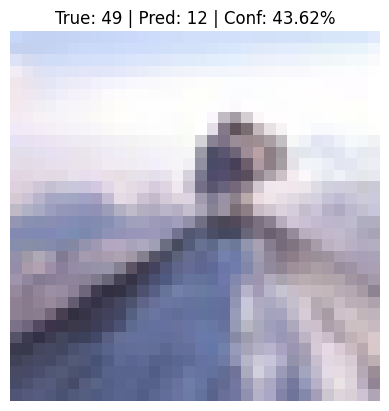

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
# =====================================================
# 1. TIỀN XỬ LÝ DỮ LIỆU
# =====================================================
# Chuyển ảnh về Tensor và chuẩn hóa dữ liệu
transform = transforms.ToTensor()

# =====================================================
# 2. NẠP DỮ LIỆU CIFAR-100
# =====================================================
# Tải và tiền xử lý dataset CIFAR-100 cho tập train
train_loader = DataLoader(
    datasets.CIFAR100('./data', train=True, download=True, transform=transform),
    batch_size=64,
    shuffle=True
)
# Tải và tiền xử lý dataset CIFAR-100 cho tập test
test_loader = DataLoader(
    datasets.CIFAR100('./data', train=False, download=True, transform=transform),
    batch_size=64
)

# =====================================================
# 3. XÂY DỰNG MÔ HÌNH CNN
# =====================================================
model = nn.Sequential(
    # Convolution Layer: 3 kênh màu -> 32 feature maps
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    # Hàm kích hoạt ReLU
    nn.ReLU(),
    # Giảm kích thước ảnh xuống 2 lần
    nn.MaxPool2d(2),
    # Convolution Layer: 32 -> 64 feature maps
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    # Hàm kích hoạt ReLU
    nn.ReLU(),
    # Giảm kích thước ảnh xuống 2 lần
    nn.MaxPool2d(2),
    # Chuyển feature map thành vector
    nn.Flatten(),
    # Fully Connected Layer
    nn.Linear(64 * 8 * 8, 128),
    # Hàm kích hoạt ReLU
    nn.ReLU(),
    # Layer đầu ra gồm 100 lớp
    nn.Linear(128, 100)
)

# =====================================================
# 4. HÀM LOSS VÀ OPTIMIZER
# =====================================================
# Hàm mất mát cho bài toán phân loại
loss_fn = nn.CrossEntropyLoss()
# Optimizer Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# =====================================================
# 5. HUẤN LUYỆN MÔ HÌNH
# =====================================================
for epoch in range(10):
    # Chuyển sang chế độ train
    model.train()
    for images, labels in train_loader:
        # Xóa gradient cũ
        optimizer.zero_grad()
        # Forward
        outputs = model(images)
        # Tính loss
        loss = loss_fn(outputs, labels)
        # Backpropagation
        loss.backward()
        # Cập nhật trọng số
        optimizer.step()
    # In loss sau mỗi epoch
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# =====================================================
# 6. ĐÁNH GIÁ MÔ HÌNH
# =====================================================
correct = 0
# Tắt gradient khi test
with torch.no_grad():
    for images, labels in test_loader:
        # Forward
        outputs = model(images)
        # Lấy lớp có xác suất cao nhất
        pred = outputs.argmax(1)
        # Đếm số dự đoán đúng
        correct += (pred == labels).sum().item()

# =====================================================
# 7. IN ĐỘ CHÍNH XÁC
# =====================================================
print("Accuracy:", correct / len(test_loader.dataset))

# =====================================================
# 8. DỰ ĐOÁN MỘT ẢNH MẪU
# =====================================================
# Danh sách tên lớp CIFAR-100
classes = test_loader.dataset.classes
# Lấy ảnh đầu tiên trong tập test
pred_image, pred_label = test_loader.dataset[0]
# Thêm chiều batch để đưa vào model
# Shape từ [3, 32, 32] -> [1, 3, 32, 32]
pred_image_input = pred_image.unsqueeze(0)
# Chuyển sang chế độ đánh giá
model.eval()
# Tắt gradient để tăng tốc suy luận
with torch.no_grad():
    # Forward ảnh qua model
    output = model(pred_image_input)
    # Chuyển output thành xác suất
    probabilities = torch.nn.functional.softmax(output, dim=1)
    # Lấy xác suất cao nhất và lớp tương ứng
    confidence, predicted_class = torch.max(probabilities, 1)
    # Lấy nhãn dự đoán
    prediction = predicted_class.item()

# =====================================================
# 9. HIỂN THỊ KẾT QUẢ DỰ ĐOÁN
# =====================================================
# Chuyển Tensor về dạng hiển thị ảnh
image_show = pred_image.permute(1, 2, 0)
# Hiển thị ảnh
plt.imshow(image_show)
# Hiển thị nhãn thật và nhãn dự đoán
plt.title(f'True: {pred_label} | Pred: {prediction} | Conf: {confidence.item()*100:.2f}%')
# Ẩn trục tọa độ
plt.axis('off')
# Hiển thị cửa sổ ảnh
plt.show()